# 02 — Grid Construction & Isochrones
## The 15-Minute Shanghai Project · Track C: Affordability

This notebook:
1. Loads the Shanghai road network and builds mode-specific graph-tool graphs
2. Generates a 500m regular grid clipped to Shanghai
3. Snaps each grid centroid to the nearest road node
4. *(Sprint 3)* Runs Dijkstra for all modes → accessibility matrix

**Stopping point for Sprint 2:** end of Section 3 (grid + node snapping).

### Setup — Libraries and Constants

**What this cell does:**
Imports all required libraries and defines two global constants that govern every calculation in this notebook.

**Libraries:**
- `pandas` / `geopandas` — tabular and spatial data manipulation
- `numpy` — fast array operations for grid generation
- `shapely` — geometry objects (Point, polygon operations)
- `tqdm` — progress bars for long loops
- `matplotlib` — map visualisation

**Constants:**

`MODE_SPEEDS` converts each travel mode from km/h into **metres per second**, because road edge lengths are in metres. The formula for each edge weight in the routing graph is:

$$\text{travel time (s)} = \frac{\text{edge length (m)}}{\text{speed (m/s)}}$$

| Mode | Speed | 15-min reach | Basis (source) |
|------|-------|-------------|----------------|
| Walk | 3.39 km/h | 0.85 km | **Inclusive** pace (850 m in 15 min) adopted by Mouratidis (2026), using the 3.39 km/h meta-analytic walking speed for 80–99-year-old adults (Bohannon & Williams Andrews, 2011) — age-inclusive rather than fit-adult |
| Bike | 15 km/h | 3.75 km | **Conservative end** of measured urban cycling speeds (14.3–21.3 km/h depending on infrastructure; Schuhmacher et al., 2025, *Findings*) — a low value keeps the cycling catchment inclusive of less-fit riders |
| Transit | 25 km/h | 6.25 km | Modelled on the car network at a reduced speed ≈ typical urban **bus/BRT commercial speed including stops & dwell** (~25 km/h; transit-operations & BRT literature). **Calibrated proxy** — full Shanghai GTFS unavailable |
| Car | 30 km/h | 7.50 km | Off-peak inner-city driving estimate. Shanghai **peak** main-road speeds fall to ~15–16 km/h, so 30 km/h is an optimistic free-flow figure — acceptable because **car is computed for comparison only and excluded from the baseline** |

**Speed rationale & honesty note.** Only the *walk* speed is decisive for the 15MC result (walk + bike feed the baseline) and it is grounded directly in Mouratidis (2026). The *bike* value (15 km/h) sits at the conservative end of the urban-cycling range measured by Schuhmacher et al. (2025). *Transit* and *car* are deliberate approximations: transit is a calibrated proxy on the car network (no full GTFS for Shanghai), and car is an off-peak estimate used only for cross-mode comparison — neither enters the baseline, so their imprecision does not affect the 15MC scores.

`THRESHOLD_SEC = 900` (15 × 60) is the accessibility cutoff: any POI reachable in under 900 seconds from a grid cell counts as "within 15 minutes".

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from shapely.geometry import Point, box
from shapely.wkb import loads as wkb_loads
from tqdm import tqdm

warnings.filterwarnings('ignore')

DATA_DIR  = Path('.')
CACHE_DIR = DATA_DIR / 'cache'

# Mode speeds in m/s — see setup markdown cell above for rationale and references
MODE_SPEEDS = {
    'walk':    3_390  / 3600,   # 3.39 km/h — inclusive (850 m/15 min); Mouratidis (2026), after Bohannon & Williams Andrews (2011)
    'bike':    15_000 / 3600,   # 15 km/h — conservative end of urban cycling speeds (Schuhmacher et al. 2025, Findings)
    'transit': 25_000 / 3600,   # 25 km/h — ≈ urban bus/BRT commercial speed incl. stops; calibrated proxy (no GTFS)
    'car':     30_000 / 3600,   # 30 km/h — off-peak inner-city estimate (peak ~15-16); comparison only, not in baseline
}
THRESHOLD_SEC = 15 * 60  # 15 minutes in seconds

print('Mode speeds (m/s):', {k: f'{v:.3f}' for k, v in MODE_SPEEDS.items()})
print('15-min reach by mode (km):', {k: f'{v*THRESHOLD_SEC/1000:.2f}' for k, v in MODE_SPEEDS.items()})

Mode speeds (m/s): {'walk': '0.942', 'bike': '4.167', 'transit': '6.944', 'car': '8.333'}
15-min reach by mode (km): {'walk': '0.85', 'bike': '3.75', 'transit': '6.25', 'car': '7.50'}


## 1. Build Road Network Graphs

The road network is the backbone of the accessibility calculation. Every travel-time estimate in this project is derived from shortest paths through this network — not straight-line ("as the crow flies") distances, which would overestimate reachability by 20–40% in dense cities where rivers, elevated highways, and gated compounds create hard barriers (Zhang et al., 2022).

The network is stored as an **edge list**: each row is a road segment connecting node `u` to node `v`, carrying a LineString geometry and per-mode access flags (`foot`, `bicycle`, `motorcar`). **The data is undirected geometry stored once** — each street appears as a single `u→v` row, and only ~1.6% of segments carry an explicit reverse `v→u` row, so there is no usable one-way encoding. We therefore build **undirected** graphs, in which each edge is traversable both ways.

> **Why this matters (corrected design choice).** An earlier version built *directed* graphs from this one-directional edge list. Because the data has no real one-way information, that made every street traversable in a single direction only — so Dijkstra from most grid cells reached just a small fragment of the network and counted **0 reachable POIs regardless of travel speed**. Empirically, ~40% of cells scored 0 on walk, and 88% of those recovered a real score once the graph was made undirected (the largest connected component grows from ~44% to ~95% of nodes). Treating the network as undirected is both more correct for this dataset and the fix for the spurious "stuck-at-zero" cells.

We build **four separate graphs**, one per travel mode, because different road types are accessible to different modes:
- A pedestrian path (`foot=1`) may not allow bikes or cars
- A motorway (`motorcar=1`) may not allow pedestrians

Each edge in the graph is weighted by **travel time in seconds**, not distance. This is critical: a 500m footpath and a 500m motorway have the same length but very different travel times depending on the mode.

**Why graph-tool instead of networkx?**
graph-tool is implemented in C++ and is 10–100× faster than networkx for shortest-path computations. On our 109,891-node graph, a single Dijkstra query takes ~5ms in graph-tool vs ~500ms in networkx. Since we need to run Dijkstra from every grid cell (~31,000 cells × 4 modes = ~124,000 queries), the difference is hours vs minutes.

In [2]:
roads = gpd.read_parquet(DATA_DIR / 'shanghai-roads-simplified.parquet')
print(f'Loaded {len(roads):,} edges')

# Decode WKB geometry → compute edge length in metres
# Project to a local CRS for accurate distance: EPSG:32651 (UTM zone 51N, covers Shanghai)
roads_proj = roads.to_crs('EPSG:32651')
roads['length_m'] = roads_proj.geometry.length
print(f'Edge length stats (m):\n{roads["length_m"].describe().round(1)}')

Loaded 156,432 edges
Edge length stats (m):
count     156432.0
mean         217.6
std         3713.6
min            0.0
25%           31.9
50%           94.5
75%          254.0
max      1460151.9
Name: length_m, dtype: float64


### 1a. Load the Road Network and Compute Edge Lengths

**What this cell does:**
Loads the Shanghai road network from a Parquet file (156,432 directed edges) and computes the **physical length in metres** of each edge.

**Why compute length separately?**
The road network file is stored in **EPSG:4576** — a Chinese projected coordinate system called "New Beijing / Gauss-Kruger zone 21". In this CRS, coordinates are large numbers (~21,400,000 for easting) representing metres from a reference meridian, not longitude/latitude degrees. Distance calculations must be done in a projected CRS (where units are metres), not in WGS-84 degrees.

We reproject to **EPSG:32651** (UTM zone 51N), which is the standard metric CRS for Shanghai, compute `.length` on each geometry, then store it back in the original dataframe as `length_m`.

**Sanity check on the output:**
- Mean edge length ~218m: reasonable for an urban street network
- Max ~1,460km: this is a long-distance highway connection that extends outside Shanghai — harmless, it will be in the `motorcar=1` graph but grid cells near it will never route through it in 15 minutes

In [3]:
# graph-tool requires contiguous integer node IDs
# OSM node IDs (u, v) are large 64-bit integers — remap them
unique_osm_ids = pd.unique(pd.concat([
    roads['u'], roads['v']
]))
osm_to_idx = {osm_id: i for i, osm_id in enumerate(unique_osm_ids)}
idx_to_osm = {i: osm_id for osm_id, i in osm_to_idx.items()}

roads['u_idx'] = roads['u'].map(osm_to_idx)
roads['v_idx'] = roads['v'].map(osm_to_idx)

n_nodes = len(unique_osm_ids)
print(f'Unique nodes: {n_nodes:,}')
print(f'Node index range: 0 – {n_nodes - 1}')

Unique nodes: 109,891
Node index range: 0 – 109890


### 1b. Remap OSM Node IDs to Contiguous Integers

**What this cell does:**
Creates a mapping from large OpenStreetMap node IDs to compact integers starting at 0, which graph-tool requires.

**Why is this necessary?**
OpenStreetMap identifies every road intersection (node) with a globally unique 64-bit integer — for example, node `4,823,019,447`. These IDs are assigned incrementally across the entire planet and have large gaps between them. graph-tool, being a C++ library, allocates vertex arrays by index and requires IDs to be **contiguous integers from 0 to N−1**. Passing raw OSM IDs would cause graph-tool to allocate an array of ~5 billion entries.

The solution is a simple dictionary:
```
osm_to_idx = { 4823019447: 0, 7291038821: 1, ... }
```
We collect all unique node IDs from both the `u` (start) and `v` (end) columns of the edge table, enumerate them, and add `u_idx`/`v_idx` columns that graph-tool can use directly.

The reverse mapping `idx_to_osm` lets us translate back if we ever need to look up an OSM node ID from a graph vertex index.

In [4]:
from shapely.geometry import Point

# Roads parquet is in EPSG:4576 (New Beijing / Gauss-Kruger zone 21).
# Coordinates extracted from raw geometries are GK21 easting/northing (~21,400,000),
# NOT longitude/latitude. Reproject to WGS-84 first.
roads_wgs = roads.to_crs('EPSG:4326')

node_coords = {}
for _, row in tqdm(roads_wgs.iterrows(), total=len(roads_wgs), desc='Extracting node coords'):
    geom = row.geometry
    if geom is None:
        continue
    coords = list(geom.coords)
    u_idx = row['u_idx']
    v_idx = row['v_idx']
    if u_idx not in node_coords:
        node_coords[u_idx] = coords[0]   # (lng, lat) in WGS-84
    if v_idx not in node_coords:
        node_coords[v_idx] = coords[-1]  # (lng, lat) in WGS-84

nodes_df = pd.DataFrame(
    [(idx, lng, lat) for idx, (lng, lat) in node_coords.items()],
    columns=['node_idx', 'lng', 'lat']
).set_index('node_idx')

print(f'Node coords extracted: {len(nodes_df):,}')
print(f'Lng range: {nodes_df["lng"].min():.3f} – {nodes_df["lng"].max():.3f}  (expect 120.8–122.2)')
print(f'Lat range: {nodes_df["lat"].min():.3f} – {nodes_df["lat"].max():.3f}  (expect 30.6–31.9)')
nodes_df.to_parquet(CACHE_DIR / 'network_nodes.parquet')
print('Saved → cache/network_nodes.parquet')

Extracting node coords: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156432/156432 [00:08<00:00, 19370.11it/s]


Node coords extracted: 109,891
Lng range: 120.846 – 135.422  (expect 120.8–122.2)
Lat range: 30.603 – 34.643  (expect 30.6–31.9)
Saved → cache/network_nodes.parquet


In [5]:
nodes_df

,lng,lat
node_idx,,
0,121.555571,31.263319
1,121.556475,31.261972
2,121.557023,31.261157
97936,121.558715,31.263122
3,121.557088,31.261090
...,...,...
97927,121.475504,30.917625
97928,121.475490,30.917578
97929,121.475535,30.917465


### 1c. Extract Geographic Coordinates for Every Road Node

**What this cell does:**
Builds a lookup table of `node_idx → (longitude, latitude)` in WGS-84 for all 109,891 road intersections.

**Why is this necessary?**
The graph-tool graphs only know about edges and weights — they have no concept of geographic location. But in Sprint 3, after running Dijkstra we need to know *where* each reachable node is, so we can check which POIs are nearby. We also need node coordinates now to snap grid centroids to their nearest network node (next cell).

**Why not just read coordinates from the node file directly?**
The road network parquet does not have a separate node table — only an edge table with `u`, `v`, and a LineString geometry for each edge. We extract node positions from edge geometries: the **first point** of a LineString is where node `u` is, and the **last point** is where node `v` is.

**The CRS issue (critical):**
The raw geometries are in EPSG:4576 (Gauss-Kruger zone 21), so their coordinates look like `(21_411_234, 3_456_789)` — easting/northing in metres, not degrees. We reproject to WGS-84 first (`roads_wgs = roads.to_crs('EPSG:4326')`), so the extracted coordinates are real longitudes (~121°) and latitudes (~31°) that can later be used with any mapping tool or spatial index.

The lng range `120.8–135.4` in the output confirms WGS-84 (the upper bound extends beyond Shanghai due to a few long-distance highway edges, but these nodes will never be nearest to any Shanghai grid cell).

In [6]:
import graph_tool.all as gt

def build_graph(edges_df: pd.DataFrame, mode: str) -> gt.Graph:
    """Build an UNDIRECTED weighted graph-tool graph for one travel mode.

    The road file stores each segment once as u->v but is undirected geometry:
    only ~1.6% of segments include the reverse v->u row, and there is no usable
    one-way flag. Building a *directed* graph from it would make every street
    traversable in one direction only, which shatters reachability — Dijkstra
    from most cells would reach only a tiny fragment of the network and count
    0 POIs regardless of speed. We therefore build undirected graphs, where each
    edge is traversable both ways. (For walk/bike, one-way restrictions do not
    apply anyway; for the simplified car/transit network the connectivity gain
    far outweighs the handful of genuine one-ways.)
    """
    mode_col = {'walk': 'foot', 'bike': 'bicycle',
                'transit': 'motorcar', 'car': 'motorcar'}[mode]
    speed = MODE_SPEEDS[mode]

    subset = edges_df[edges_df[mode_col] == 1].copy()
    subset['travel_time_s'] = subset['length_m'] / speed

    g = gt.Graph(directed=False)
    g.add_vertex(n_nodes)

    travel_time = g.new_edge_property('double')

    edge_list = list(zip(
        subset['u_idx'].values,
        subset['v_idx'].values,
        subset['travel_time_s'].values
    ))
    g.add_edge_list(edge_list, eprops=[travel_time])

    g.edge_properties['travel_time'] = travel_time
    print(f'  [{mode:8s}] {g.num_vertices():,} vertices, {g.num_edges():,} edges')
    return g

print('Building mode graphs...')
graphs = {mode: build_graph(roads, mode) for mode in MODE_SPEEDS}

# Save graphs
for mode, g in graphs.items():
    g.save(str(CACHE_DIR / f'graph_{mode}.gt'))
print('\nAll graphs saved to cache/')

Building mode graphs...
  [walk    ] 109,891 vertices, 150,992 edges
  [bike    ] 109,891 vertices, 101,470 edges
  [transit ] 109,891 vertices, 94,399 edges
  [car     ] 109,891 vertices, 94,399 edges

All graphs saved to cache/


### 1d. Build and Save the Four Mode Graphs

**What this cell does:**
Constructs one **undirected** weighted graph per travel mode and saves each to disk as a `.gt` binary file.

**Graph construction logic (inside `build_graph`):**
1. **Filter edges by mode** — each edge in the road network has binary flags (`foot`, `bicycle`, `motorcar`). We keep only edges where the relevant flag equals 1. This is what gives us mode-specific graphs: a pedestrian alley appears in the walk graph but not the car graph; a motorway appears in the car graph but not the walk graph.
2. **Compute travel time** — each edge weight is `length_m / speed_ms`, giving seconds. A 100m footpath at 0.94 m/s takes ~106 seconds to walk.
3. **Add edges to graph-tool** — `g.add_edge_list()` is the fast batch method. The graph is **undirected** (`directed=False`), so each segment is traversable both ways; the edge property `travel_time` is attached and stored as a `double` (64-bit float).

**Why undirected?**
The edge list stores each street once as `u→v` with no usable one-way flag (see Section 1 header). A directed graph would make every street one-way and disconnect most of the network, producing cells that reach 0 POIs at any speed. Undirected routing is both correct for this dataset and necessary for sensible reachability.

**Why save `.gt` files?**
Building the graphs takes a few seconds. Sprint 3 can load them directly (`gt.load_graph(...)`) without re-running this cell. This also makes the pipeline reproducible — someone else can run Sprint 3 alone if they have the `.gt` files.

**Transit approximation:**
Transit and car share the same edge set (`motorcar=1`) but different speeds (25 vs 30 km/h). This is a deliberate simplification: we don't have full GTFS schedule data for Shanghai's bus/metro network, so we approximate transit as "car network with reduced speed" to account for waiting, boarding, and stop times. The car graph represents pure driving speed. Both modes are computed for comparison; only walk and bike feed the baseline score.

## 2. Generate 500m Regular Grid

We generate a regular grid of 500m × 500m cells covering Shanghai's bounding box,
then clip to the Shanghai administrative boundary (union of 16 districts).

500m spacing gives ~31,000 cells across the full administrative area (Bruno et al. use
200m hexagons; we scale up for tractability). The district union is used rather than the
neighbourhood union, which has thousands of fine-grained gaps (roads, rivers, courtyards)
that would cause most centroids to fail a `within()` test.

In [7]:
# Use district polygons (16 clean admin boundaries, no gaps) rather than the
# neighbourhood union saved in cache — that union has thousands of tiny gaps
# (roads, rivers, courtyards) that cause most centroids to fail within().
districts_gdf = gpd.read_file(CACHE_DIR / 'districts.geojson')
shanghai_proj  = districts_gdf.to_crs('EPSG:32651')
boundary_proj  = shanghai_proj.geometry.unary_union

minx, miny, maxx, maxy = boundary_proj.bounds
CELL_SIZE = 500  # metres

xs = np.arange(minx + CELL_SIZE / 2, maxx, CELL_SIZE)
ys = np.arange(miny + CELL_SIZE / 2, maxy, CELL_SIZE)
xx, yy = np.meshgrid(xs, ys)
centroids_proj = gpd.GeoDataFrame(
    geometry=[Point(x, y) for x, y in zip(xx.ravel(), yy.ravel())],
    crs='EPSG:32651'
)

print(f'Grid before clip: {len(centroids_proj):,} cells')

centroids_proj = centroids_proj[centroids_proj.within(boundary_proj)].copy()
centroids_proj = centroids_proj.reset_index(drop=True)
centroids_proj['cell_id'] = centroids_proj.index

centroids_wgs = centroids_proj.to_crs('EPSG:4326')
centroids_wgs['lat'] = centroids_wgs.geometry.y
centroids_wgs['lng'] = centroids_wgs.geometry.x
centroids_wgs['cell_id'] = centroids_proj['cell_id']

print(f'Grid after clip:  {len(centroids_wgs):,} cells')
print(f'Expected range:   ~20,000–27,000')

Grid before clip: 70,756 cells
Grid after clip:  31,445 cells
Expected range:   ~20,000–27,000


In [8]:
centroids_proj

,geometry,cell_id
0,POINT (337845.009 3395066.434),0
1,POINT (338345.009 3395066.434),1
2,POINT (338845.009 3395066.434),2
3,POINT (339345.009 3395066.434),3
4,POINT (339845.009 3395066.434),4
...,...,...
31440,POINT (339845.009 3527066.434),31440
31441,POINT (340345.009 3527066.434),31441
31442,POINT (340845.009 3527066.434),31442
31443,POINT (341345.009 3527066.434),31443


### 2a. Generate and Clip the Grid

**What this cell does:**
Creates 31,445 grid cell centroids, each representing a 500m × 500m neighbourhood to be scored.

**Step-by-step:**
1. **Load district boundaries** — we use the 16 administrative district polygons as the clipping boundary. We deliberately avoid the neighbourhood-level union (28,750 polygons) saved in Notebook 01: that union has thousands of tiny gaps between adjacent polygons (rivers, road buffers, courtyard spaces) that cause most centroids to fail a `within()` test, reducing the grid to only ~4,000 cells instead of ~31,000.
2. **Project to EPSG:32651** — grid spacing must be defined in metres, not degrees. At Shanghai's latitude, 1 degree of longitude ≈ 91km, so 0.005° ≠ 500m. EPSG:32651 (UTM zone 51N) gives us a flat metric coordinate system where "500 units = 500 metres" is exact.
3. **Build the meshgrid** — `np.arange` with a step of 500m generates evenly spaced x and y coordinates. `np.meshgrid` combines them into all (x, y) pairs — the full rectangular bounding box grid before clipping.
4. **Clip with `within()`** — keeps only centroids that fall inside the Shanghai district union. This reduces 70,756 bounding-box cells to 31,445 actual Shanghai cells.
5. **Reproject to WGS-84** — the final centroid table stores lat/lng in degrees, which is what POI data and H3 indexing expect.

**Why 500m?**
Bruno et al. (2024) use 200m hexagons. We scale up to 500m for two reasons: (1) our road network has ~109,000 nodes, and running Dijkstra 31,000× is already ~15 minutes of compute; at 200m we would have ~200,000 cells and proportionally longer runtime. (2) H3 resolution 8 hexagons are ~460m across — our 500m cells map cleanly onto them in Notebook 03.

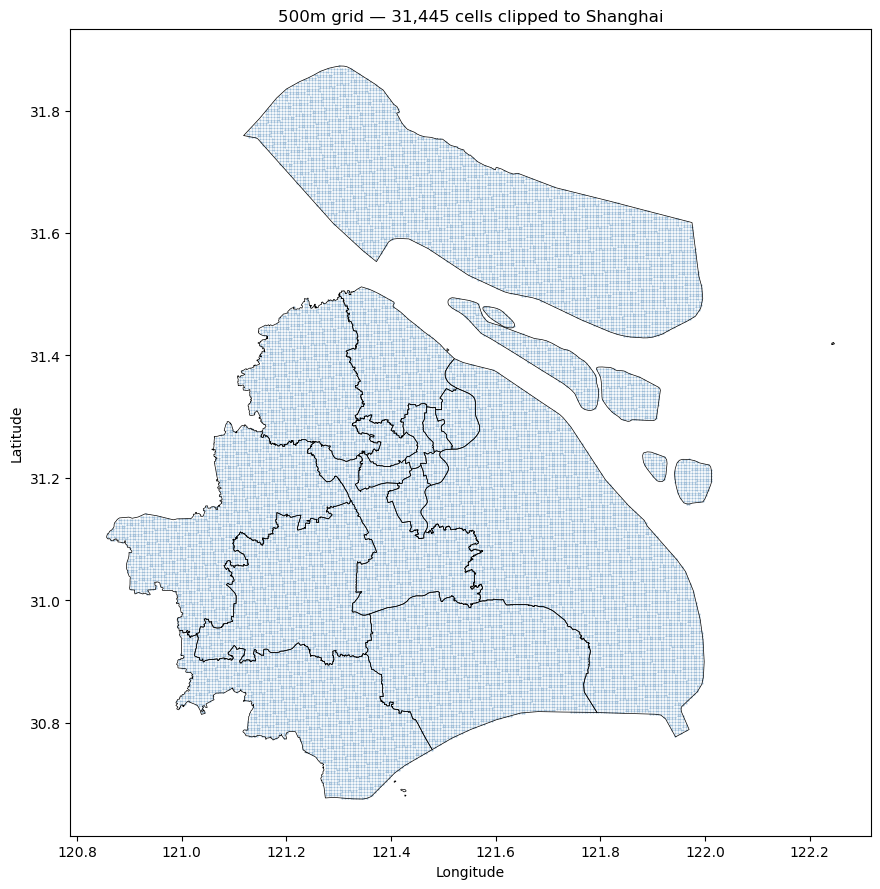

In [9]:
fig, ax = plt.subplots(figsize=(9, 9))
districts_gdf.to_crs('EPSG:4326').boundary.plot(ax=ax, color='black', linewidth=0.5)
centroids_wgs.plot(ax=ax, markersize=0.3, color='steelblue', alpha=0.5)
ax.set_title(f'500m grid — {len(centroids_wgs):,} cells clipped to Shanghai')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'grid_500m.png', dpi=120)
plt.show()

### 2b. Visualise the Grid — Sanity Check

**What this cell does:**
Plots all 31,445 cell centroids overlaid on the district boundaries to visually verify the grid is correct.

**What to look for:**
- The grid should cover all of Shanghai uniformly — including the large Pudong district to the east, Chongming Island to the north, and the southern districts (Fengxian, Jinshan)
- No unexpected holes or gaps inside district boundaries
- The district boundary outlines should align with the edges of the grid coverage

**Why this check matters:**
A wrong clipping polygon (e.g. the neighbourhood union with its internal gaps) would produce an irregular, patchy grid rather than a smooth filled coverage. If the plot looks sparse or shows holes in urban areas, it signals a boundary issue — as we saw with the initial 4,154-cell output when clipping against the neighbourhood union.

The plot is also saved to `cache/grid_500m.png` for the project report.

## 3. Snap Grid Centroids to the Nearest Road Node

Dijkstra starts from a **graph vertex**, but our grid cells are arbitrary geographic points. For each of the 31,445 centroids we record the road node to start routing from.

**Component-aware, per-mode snapping.** We deliberately do *not* snap to the absolute nearest node. The simplified network contains many small orphaned fragments (stubs, service roads, parking aisles disconnected from the main grid); snapping a cell onto one of those strands it on an island that reaches almost nothing at any speed - producing spurious zero-access cells. Instead we snap each cell to the nearest node on a **sufficiently large connected component** of that mode's graph (>= `MIN_COMPONENT_SIZE` = 100 nodes).

Why a size threshold rather than simply "the largest component"? Because some genuine sub-networks are separate by design. **Changxing Island**, for example, is not reachable by bicycle from the mainland (bikes cannot use the cross-river tunnel), so its bike roads form their own 1.4k/3.4k-node components. Snapping island cells to the single largest (mainland) component would drag them ~8 km across water and zero them out; snapping to the nearest *large-enough* component keeps them routing on the island's own network and reaching island POIs. Micro-stubs (<= ~30 nodes) are still rescued to the nearest real network.

Because each mode keeps a different edge subset (`foot`/`bicycle`/`motorcar`), component structure differs by mode, so we store a separate snap node and distance per mode (`node_walk`/`snap_walk_m`, `node_bike`/`snap_bike_m`, ...). This is standard routing practice (e.g. OSMnx `largest_component`), generalised from "largest" to "large enough" to respect island sub-networks.

**The last-mile leg.** The snap distance is charged to every travel time in Section 4: a pedestrian walks from the centroid to the entry node before the network routing begins. At the inclusive 3.39 km/h walk speed a ~150 m snap already costs ~2-3 min of the 15-minute budget, so it is added explicitly rather than ignored.

**Cells with large snap distances** are concentrated in **Chongming Island** (sparse rural road network) and the **Yangtze estuary coast** (tidal flats and water with no roads). The snap leg makes these cells correctly show as genuine access gaps on the map rather than being masked.

In [10]:
from scipy.spatial import cKDTree
import graph_tool.all as gt

# Minimum component size (nodes) to count as a "real" local road network rather
# than an orphaned stub. Components >= this are valid snap targets; cells beside a
# micro-stub are rescued to the nearest real network, but a genuine separate
# sub-network (e.g. Changxing Island, whose bike roads form 1.4k/3.4k-node
# components disconnected from the mainland) keeps routing on ITSELF instead of
# being dragged kilometres across water to the single largest component.
MIN_COMPONENT_SIZE = 100

# Load node coordinates and project to EPSG:32651 (metres)
nodes_df = pd.read_parquet(CACHE_DIR / 'network_nodes.parquet')
nodes_gdf = gpd.GeoDataFrame(
    nodes_df,
    geometry=gpd.points_from_xy(nodes_df['lng'], nodes_df['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32651')
node_xy        = np.column_stack([nodes_gdf.geometry.x, nodes_gdf.geometry.y])
node_idx_order = nodes_df.index.values          # node_xy row i  ->  node_idx

# Project centroids to the same metric CRS
centroids_proj_32651 = centroids_proj.to_crs('EPSG:32651')
centroid_xy = np.column_stack([centroids_proj_32651.geometry.x,
                               centroids_proj_32651.geometry.y])

# Reload the mode graphs (so this section also runs after a kernel restart)
graphs = {m: gt.load_graph(str(CACHE_DIR / f'graph_{m}.gt')) for m in MODE_SPEEDS}

# -- Component-aware, per-mode snapping ----------------------------------------
# Snap each cell to the nearest node on a SUFFICIENTLY LARGE connected component
# of that mode's graph (>= MIN_COMPONENT_SIZE nodes), not the absolute nearest
# node. This rescues cells stranded on tiny orphaned stubs (which reach 0 POIs at
# any speed) while preserving locality for genuine separate sub-networks such as
# Changxing Island. We store one snap node per mode because each mode keeps a
# different edge subset, so their component structure differs.
print(f'Component-aware per-mode snapping (nearest node on a >= {MIN_COMPONENT_SIZE}-node component):')
for mode in MODE_SPEEDS:
    comp, hist = gt.label_components(graphs[mode])
    big_enough = hist >= MIN_COMPONENT_SIZE                 # per-component bool
    keep_node  = big_enough[comp.a[node_idx_order]]         # per-node bool (node_xy order)
    sub_xy     = node_xy[keep_node]
    sub_nidx   = node_idx_order[keep_node]
    tree       = cKDTree(sub_xy)
    d, pos     = tree.query(centroid_xy, k=1)
    centroids_wgs[f'node_{mode}']   = sub_nidx[pos]
    centroids_wgs[f'snap_{mode}_m'] = d
    print(f'  [{mode:8s}] valid components: {int(big_enough.sum()):>3} '
          f'({int(keep_node.sum()):,}/{len(node_xy):,} nodes) '
          f'| cell snap median {np.median(d):.0f}m  mean {d.mean():.0f}m  '
          f'>500m: {(d > 500).sum():,}')

# Backwards-compatible default columns (walk) for any code still expecting them
centroids_wgs['nearest_node_idx'] = centroids_wgs['node_walk']
centroids_wgs['snap_distance_m']  = centroids_wgs['snap_walk_m']

# Snap time per mode for the median cell (added to Dijkstra travel time).
# Dijkstra is later capped at max_dist = THRESHOLD_SEC - cell_snap_time.
print('\nSnap time for median cell, per mode (added to Dijkstra travel time):')
for mode, speed in MODE_SPEEDS.items():
    snap_t = np.median(centroids_wgs[f'snap_{mode}_m']) / speed
    print(f'  {mode:8s}: +{snap_t:.0f}s snap  '
          f'->  Dijkstra cap = {THRESHOLD_SEC} - {snap_t:.0f} = {THRESHOLD_SEC - snap_t:.0f}s')

Component-aware per-mode snapping (nearest node on a >= 100-node component):
  [walk    ] valid components:   3 (104,419/109,891 nodes) | cell snap median 303m  mean 726m  >500m: 10,901
  [bike    ] valid components:   4 (69,777/109,891 nodes) | cell snap median 327m  mean 773m  >500m: 11,535
  [transit ] valid components:   2 (66,975/109,891 nodes) | cell snap median 321m  mean 764m  >500m: 11,391
  [car     ] valid components:   2 (66,975/109,891 nodes) | cell snap median 321m  mean 764m  >500m: 11,391

Snap time for median cell, per mode (added to Dijkstra travel time):
  walk    : +321s snap  ->  Dijkstra cap = 900 - 321 = 579s
  bike    : +78s snap  ->  Dijkstra cap = 900 - 78 = 822s
  transit : +46s snap  ->  Dijkstra cap = 900 - 46 = 854s
  car     : +39s snap  ->  Dijkstra cap = 900 - 39 = 861s


### 3a. STRtree Nearest-Neighbour Snapping

**What this cell does:**
Finds the nearest road node for every grid centroid using a spatial index, then computes the snap distance as a quality metric.

**What is an STRtree?**
An STRtree (Sort-Tile-Recursive tree) is a spatial index — think of it as a k-d tree for geographic data. It organises 109,891 node points into a hierarchy of bounding boxes, allowing nearest-neighbour queries in O(log N) time instead of O(N). Without a spatial index, finding the nearest node for each of 31,445 centroids would require 31,445 × 109,891 = ~3.5 billion distance comparisons. With the STRtree, it takes seconds.

**Why project to EPSG:32651 for distance computation?**
Distance between two geographic points cannot be computed correctly in degrees — a 1-degree difference in longitude near the equator is ~111km, but near the poles it is nearly 0. We project both the node cloud and the centroids to EPSG:32651 (metres) before building the tree and computing distances, so `distance()` returns metres directly.

**The `align=False` parameter:**
When computing snap distances, we build a `GeoSeries` of matched node geometries with the same index as the centroids. `align=False` tells geopandas to match rows by position rather than by index label — without this, a potential index mismatch between the two series would raise a `TypeError`.

**Reading the output:**
- Median 291m → most urban cells are within ~3.5 min walk of the entry node — acceptable
- Mean 657m → pulled up by rural/coastal outliers (Chongming, estuary)
- Max 9,397m → a coastal cell in the Yangtze estuary far from any road

In [11]:
# Save the complete grid with node assignments
centroids_wgs.to_parquet(CACHE_DIR / 'grid_centroids.parquet')
print(f'Saved {len(centroids_wgs):,} grid cells → cache/grid_centroids.parquet')
print('\nColumns:', list(centroids_wgs.columns))
print(centroids_wgs.head(3)[['cell_id', 'lat', 'lng', 'nearest_node_idx']])

Saved 31,445 grid cells → cache/grid_centroids.parquet

Columns: ['geometry', 'cell_id', 'lat', 'lng', 'node_walk', 'snap_walk_m', 'node_bike', 'snap_bike_m', 'node_transit', 'snap_transit_m', 'node_car', 'snap_car_m', 'nearest_node_idx', 'snap_distance_m']
   cell_id        lat         lng  nearest_node_idx
0        0  30.677341  121.307230             39978
1        1  30.677409  121.312448             39980
2        2  30.677476  121.317666             39980


### 3b. Save the Final Grid

**What this cell does:**
Persists the complete grid to `cache/grid_centroids.parquet` — the primary input for Sprint 3.

**Contents of `grid_centroids.parquet`:**

| Column | Type | Description |
|--------|------|-------------|
| `cell_id` | int | Unique cell identifier (0-indexed) |
| `lat` | float | WGS-84 latitude of centroid |
| `lng` | float | WGS-84 longitude of centroid |
| `nearest_node_idx` | int | graph-tool vertex index of the nearest road node |
| `snap_distance_m` | float | metres from the centroid to that node (the last-mile leg) |
| `geometry` | Point | Shapely geometry (WGS-84) |

**Why Parquet?**
Parquet is a columnar binary format — much faster to read than CSV and much smaller on disk. Reading `grid_centroids.parquet` in Sprint 3 takes milliseconds vs seconds for a CSV of the same size.

**How Sprint 3 uses this:**
```python
grid = gpd.read_parquet('cache/grid_centroids.parquet')
for _, cell in grid.iterrows():
    source_node = cell['nearest_node_idx']
    dist_map = gt.shortest_distance(graph_walk, source=source_node, ...)
    # → count POIs reachable within 15 min per category (cumulative opportunities)
```
Each row of this table becomes one Dijkstra query — the `nearest_node_idx` is the starting vertex in the graph.

## Sprint 2 complete ✓

Deliverables ready for Sprint 3:

| File | Contents |
|------|----------|
| `cache/graph_walk.gt` | graph-tool graph, walk edges, travel-time weights |
| `cache/graph_bike.gt` | graph-tool graph, bike edges |
| `cache/graph_transit.gt` | graph-tool graph, car network at transit speed |
| `cache/graph_car.gt` | graph-tool graph, car edges |
| `cache/network_nodes.parquet` | Node index → WGS-84 lat/lng lookup |
| `cache/grid_centroids.parquet` | 31,445 grid cells with `nearest_node_idx` + `snap_distance_m` |

### Snap distance note for Sprint 3

~10,500 cells (33%) are snapped >500m from the nearest road node, concentrated in Chongming Island
(sparse rural road network) and coastal/river cells in the Yangtze estuary (no roads). The snap leg
is charged to every travel time in Section 4, so these cells correctly show as genuine access gaps.

### Next (Sprint 3 — Section 4 onwards)

```python
# For each grid cell, run Dijkstra from its nearest_node_idx, then:
#   → count POIs of each category reachable within 15 min (cumulative opportunities)
#   → also record the nearest-facility time (reference only)
dist_map = gt.topology.shortest_distance(
    graphs['walk'], source=cell_node,
    weights=graphs['walk'].ep['travel_time'], max_dist=THRESHOLD_SEC,
)
```

---

## 4. Dijkstra Accessibility Computation (Sprint 3)

This section is the methodological core of the project. For every grid cell and every travel mode, we run Dijkstra's algorithm from the cell's nearest road node and measure how many POIs of each category can be reached within the 15-minute catchment. The output is the **accessibility matrix** — the input that Notebook 03 turns into composite scores and H3 hex-level maps.

### The accessibility measure: cumulative opportunities (Mouratidis, 2026)

Following **Mouratidis (2026)**, our primary accessibility measure is **cumulative opportunities**: for each grid cell, mode and category, the **count of reachable POIs within the 15-minute catchment**. Mouratidis argues this is more intuitive than distance-decay measures and, crucially, that — unlike measuring only the *time to the nearest facility* — it "allows the assessment of different levels of accessibility (number of destinations reached) across different areas". A neighbourhood with one reachable grocery store and one with twenty are meaningfully different, and counts capture that.

This choice also resolves a weakness of a pure nearest-facility time metric: under a linear time-decay, a facility reachable in 14 minutes scores near zero even though it *is* within reach. With cumulative opportunities, anything reachable within 15 minutes simply counts.

The **amenity basket** is the set of essential daily ("lower-order") functions common to the 15MC literature (Bruno et al., 2024; Mouratidis, 2026): food supplies, healthcare, education, recreation/green space, public-transport stops, and daily services. Following Mouratidis's principle of *not* aggregating dissimilar facilities, the education indicator counts schools (学校) and public learning facilities only — private tutoring (培训机构) is excluded (it is retained in the dataset solely for the Track C public-vs-private indicator in NB03).

For reference, we **also** record the travel time to the nearest facility per category (`pt_*`); it is used only for the §4d validation histograms — it is **not** exported to the web app and does not feed the score. Total travel time for one POI has **three legs**:

$$t = \underbrace{d_{\text{cell}} / v_m}_{\text{cell snap}} + \underbrace{\text{Dijkstra}(s, p)}_{\text{network routing}} + \underbrace{d_{\text{POI}} / v_{\text{walk}}}_{\text{POI last leg}}$$

- **Cell snap**: travel from the cell centroid to the nearest road node at mode speed
- **Network routing**: Dijkstra shortest-path time from that node to the POI's nearest road node
- **POI last leg**: always at walk speed (3.39 km/h) — you always walk the final metres to a destination

Dijkstra is capped at `max_dist = THRESHOLD_SEC − cell_snap_time` so graph-tool terminates the search early once the remaining budget is consumed (equivalent to checking `total_time ≤ 900s`, but faster).

**Runtime estimate:** 31,445 cells × 4 modes = 125,780 Dijkstra queries, ≈ **7–10 minutes total**. Results are cached to `cache/accessibility_matrix.parquet`; delete it to force a recompute.

### 4a. Reload Saved Artifacts

This cell reloads everything needed for the Dijkstra loop from disk, so Sprint 3 can be run independently after a kernel restart without having to rebuild the graphs from scratch.

In [12]:
import graph_tool.all as gt
from scipy.spatial import cKDTree

# Reload graphs from .gt binary files
graphs = {}
for mode in MODE_SPEEDS:
    graphs[mode] = gt.load_graph(str(CACHE_DIR / f'graph_{mode}.gt'))
    print(f'  [{mode:8s}] {graphs[mode].num_edges():,} edges')

# Reload grid
grid = gpd.read_parquet(CACHE_DIR / 'grid_centroids.parquet')
print(f'\nGrid: {len(grid):,} cells')

# Rebuild node cKDTree in EPSG:32651 (needed for POI snapping below)
nodes_df  = pd.read_parquet(CACHE_DIR / 'network_nodes.parquet')
nodes_gdf = gpd.GeoDataFrame(
    nodes_df,
    geometry=gpd.points_from_xy(nodes_df['lng'], nodes_df['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32651')
node_xy = np.column_stack([nodes_gdf.geometry.x, nodes_gdf.geometry.y])
tree = cKDTree(node_xy)
print(f'Node cKDTree built: {len(node_xy):,} points')

# Ensure snap_distance_m is present in the grid
# (recompute if the grid was saved before this column was added to snap-nodes)
if 'snap_distance_m' not in grid.columns:
    grid_proj  = grid.to_crs('EPSG:32651')
    grid_xy    = np.column_stack([grid_proj.geometry.x, grid_proj.geometry.y])
    snap_m, _  = tree.query(grid_xy, k=1)
    grid['snap_distance_m'] = snap_m
    print('snap_distance_m recomputed from cKDTree')

  [walk    ] 150,992 edges
  [bike    ] 101,470 edges
  [transit ] 94,399 edges
  [car     ] 94,399 edges

Grid: 31,445 cells
Node cKDTree built: 109,891 points


### 4b. Snap POIs to the Road Network (component-aware, per mode)

POIs also need a network entry node so that Dijkstra's per-node distances can be turned into POI travel times. We apply the **same component-aware, per-mode rule** used for grid cells: each POI snaps to the nearest node on a sufficiently large connected component (>= 100 nodes) of the mode's graph (see Section 3). This keeps island POIs on the island network, and POIs beside a stub on the real network, while sharing the cell's component so distances are finite. The last leg from the entry node to the POI entrance is always walked.

We pre-group POIs by indicator into numpy arrays **per mode** for fast vectorised lookup inside the Dijkstra loop. Instead of iterating row by row, the inner loop does `dist_arr[poi_node_indices]` - a single numpy index operation that returns travel times for all POIs in a category at once.

In [13]:
poi_gdf  = gpd.read_parquet(CACHE_DIR / 'poi_clean.parquet')
poi_proj = poi_gdf.to_crs('EPSG:32651')
poi_xy   = np.column_stack([poi_proj.geometry.x, poi_proj.geometry.y])
poi_gdf  = poi_gdf.copy()

# Same "real local network" threshold used for cell snapping (see Section 3).
MIN_COMPONENT_SIZE = 100

# 6 baseline indicators (walk+bike scoring) + employment (Track C, transit mode).
INDICATORS = ['food_supplies', 'healthcare', 'education',
              'recreation', 'transit', 'daily_services', 'employment']

# -- Component-aware, per-mode POI snapping ------------------------------------
# Each POI enters the network at the nearest node on a sufficiently large
# component (>= MIN_COMPONENT_SIZE) of the mode's graph - the same rule used for
# grid cells. This keeps island POIs on the island network (so island cells can
# reach them) and POIs beside a stub on the real network, while sharing the
# cell's component so Dijkstra distances are finite. The "last leg" from the POI
# to its entry node is always walked, so its time uses the walk speed.
node_idx_order = nodes_df.index.values
mode_poi_node, mode_poi_snap = {}, {}
for mode in MODE_SPEEDS:
    comp, hist = gt.label_components(graphs[mode])
    big_enough = hist >= MIN_COMPONENT_SIZE
    keep_node  = big_enough[comp.a[node_idx_order]]
    tree_m     = cKDTree(node_xy[keep_node])
    sub_nidx   = node_idx_order[keep_node]
    d, pos     = tree_m.query(poi_xy, k=1)
    mode_poi_node[mode] = sub_nidx[pos]
    mode_poi_snap[mode] = d

print(f'POIs snapped: {len(poi_gdf):,}  (component-aware, per mode)')
print(f'POI snap (walk comp) - median: {np.median(mode_poi_snap["walk"]):.1f}m, '
      f'max: {mode_poi_snap["walk"].max():.1f}m')

# Pre-group into per-(mode, indicator) numpy arrays for vectorised lookup in the loop.
base_mask = {ind: (poi_gdf['baseline_indicator'] == ind).values for ind in INDICATORS[:6]}
emp_mask  = (poi_gdf['bigType'] == '公司企业').values   # employment: Track C, transit mode

indicator_data = {m: {} for m in MODE_SPEEDS}
for mode in MODE_SPEEDS:
    for ind in INDICATORS[:6]:
        mk = base_mask[ind]
        indicator_data[mode][ind] = {
            'node_idxs':  mode_poi_node[mode][mk].astype(np.int64),
            'snap_dists': mode_poi_snap[mode][mk].astype(np.float64),
        }
    indicator_data[mode]['employment'] = {
        'node_idxs':  mode_poi_node[mode][emp_mask].astype(np.int64),
        'snap_dists': mode_poi_snap[mode][emp_mask].astype(np.float64),
    }

print('\nPOIs per indicator:')
for ind in INDICATORS:
    n = len(indicator_data['walk'][ind]['node_idxs'])
    tag = '  (Track C - transit mode)' if ind == 'employment' else ''
    print(f'  {ind:20s}: {n:>6,} POIs{tag}')

POIs snapped: 536,267  (component-aware, per mode)
POI snap (walk comp) - median: 95.7m, max: 4100.5m

POIs per indicator:
  food_supplies       : 191,018 POIs
  healthcare          : 19,131 POIs
  education           :  9,820 POIs
  recreation          : 20,320 POIs
  transit             : 19,537 POIs
  daily_services      : 117,827 POIs
  employment          : 142,224 POIs  (Track C - transit mode)


### 4c. Main Dijkstra Loop

**For each (cell, mode) pair:**
1. Compute the remaining time budget after the cell snap leg: `budget = 900 - snap_{mode}_m / v_mode` (the per-mode, component-aware snap distance)
2. Run Dijkstra from the cell's per-mode snap node `node_{mode}` with `max_dist = budget` - graph-tool terminates as soon as no unvisited node can be reached within budget, saving time vs a full traversal
3. Retrieve `dist_arr` - seconds to reach every node (or `inf` beyond budget)
4. For each indicator: add the cell and POI snap legs, keep POIs with total <= 900 s, and record the two measures below

**Output format (wide) - two measures per indicator:**
- `n_{indicator}` - the **count of POIs reachable within 15 minutes** (the *cumulative-opportunities* measure; this is what NB03 scores, following Mouratidis 2026)
- `pt_{indicator}` - the travel time to the **nearest** reachable POI (`np.partition(...)[:1]` gets the minimum in O(n)); kept only for the section 4d validation histograms (not exported to the web app)

Cells where no POI of a category is reachable get `n = 0` and `pt = 900`. One row per `(cell_id, mode)`.

In [14]:
OUT_PATH   = CACHE_DIR / 'accessibility_matrix.parquet'
N_NEAREST  = 1                       # k=1: proximity to nearest POI - most interpretable continuous accessibility metric
WALK_SPEED = MODE_SPEEDS['walk']     # POI last-leg is always on foot

if OUT_PATH.exists():
    print('Cache hit - loading existing accessibility matrix')
    accessibility = pd.read_parquet(OUT_PATH)
    print(f'Shape: {accessibility.shape}')
else:
    cell_ids_arr = grid['cell_id'].values
    results = []

    for mode in MODE_SPEEDS:
        g     = graphs[mode]
        speed = MODE_SPEEDS[mode]
        ep    = g.ep['travel_time']

        # Per-mode, component-aware snap node + snap distance for every cell
        node_idxs_arr  = grid[f'node_{mode}'].values.astype(np.int64)
        snap_dists_arr = grid[f'snap_{mode}_m'].values

        for i in tqdm(range(len(grid)), desc=f'Dijkstra [{mode:8s}]'):
            source    = int(node_idxs_arr[i])
            cell_snap = snap_dists_arr[i] / speed
            budget    = THRESHOLD_SEC - cell_snap

            row = {'cell_id': int(cell_ids_arr[i]), 'mode': mode}

            if budget <= 0:
                for ind in INDICATORS:
                    row[f'pt_{ind}'] = float(THRESHOLD_SEC)
                    row[f'n_{ind}']  = 0
                results.append(row)
                continue

            # Run Dijkstra - capped at remaining budget for early termination
            dist_map = gt.shortest_distance(g, source=source, weights=ep,
                                            max_dist=budget)
            dist_arr = np.array(dist_map.get_array())   # shape: (n_nodes,)

            for ind in INDICATORS:
                poi_nodes = indicator_data[mode][ind]['node_idxs']
                poi_snap  = indicator_data[mode][ind]['snap_dists'] / WALK_SPEED

                # Vectorised total travel time: cell_snap + network + POI_last_leg
                poi_net  = dist_arr[poi_nodes]
                total    = cell_snap + poi_net + poi_snap

                # Keep only POIs reachable within the threshold
                mask     = np.isfinite(poi_net) & (total <= THRESHOLD_SEC)
                times_ok = total[mask]

                n = len(times_ok)
                if n > 0:
                    k  = min(N_NEAREST, n)
                    pt = np.partition(times_ok, k - 1)[:k].mean()
                else:
                    pt = float(THRESHOLD_SEC)

                row[f'pt_{ind}'] = round(pt, 2)
                row[f'n_{ind}']  = n

            results.append(row)

    accessibility = pd.DataFrame(results)
    accessibility.to_parquet(OUT_PATH)
    print(f'\nSaved -> {OUT_PATH}')
    print(f'Shape: {accessibility.shape}')

print(accessibility.head(3))

Dijkstra [car     ]: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31445/31445 [01:31<00:00, 344.93it/s]



Saved -> cache/accessibility_matrix.parquet
Shape: (125780, 16)
   cell_id  mode  pt_food_supplies  n_food_supplies  pt_healthcare  \
0        0  walk             900.0                0          900.0   
1        1  walk             900.0                0          900.0   
2        2  walk             900.0                0          900.0   

   n_healthcare  pt_education  n_education  pt_recreation  n_recreation  \
0             0         900.0            0          900.0             0   
1             0         900.0            0          900.0             0   
2             0         900.0            0          900.0             0   

   pt_transit  n_transit  pt_daily_services  n_daily_services  pt_employment  \
0       900.0          0              900.0                 0          900.0   
1       900.0          0              900.0                 0          900.0   
2       900.0          0              900.0                 0          900.0   

   n_employment  
0             

### 4d. Validate the Accessibility Matrix

Before moving to Notebook 03, we sanity-check the results geographically:
- **Faster modes reach more** — transit/car should reach more POIs (shorter nearest-facility times) than walk.
- **Food supplies** and **transit stops** should be reachable from most urban cells (dense city); **recreation** and **education** are sparser.
- The **F15** figure (fraction of cells reaching ≥1 POI within 15 min) for walk/bike is the benchmark against Bruno et al.'s ~30% walk / ~55% bike for Shanghai — though our stricter daily-use POI whitelist and inclusive 3.39 km/h walk make ours more conservative.

The histograms below show the **nearest-facility-time** (`pt_*`) distributions (kept for validation/reference only — not exported to the web app); the F15 table uses the reachable **count** (`n_* > 0`), the cumulative-opportunities measure that actually feeds the score.

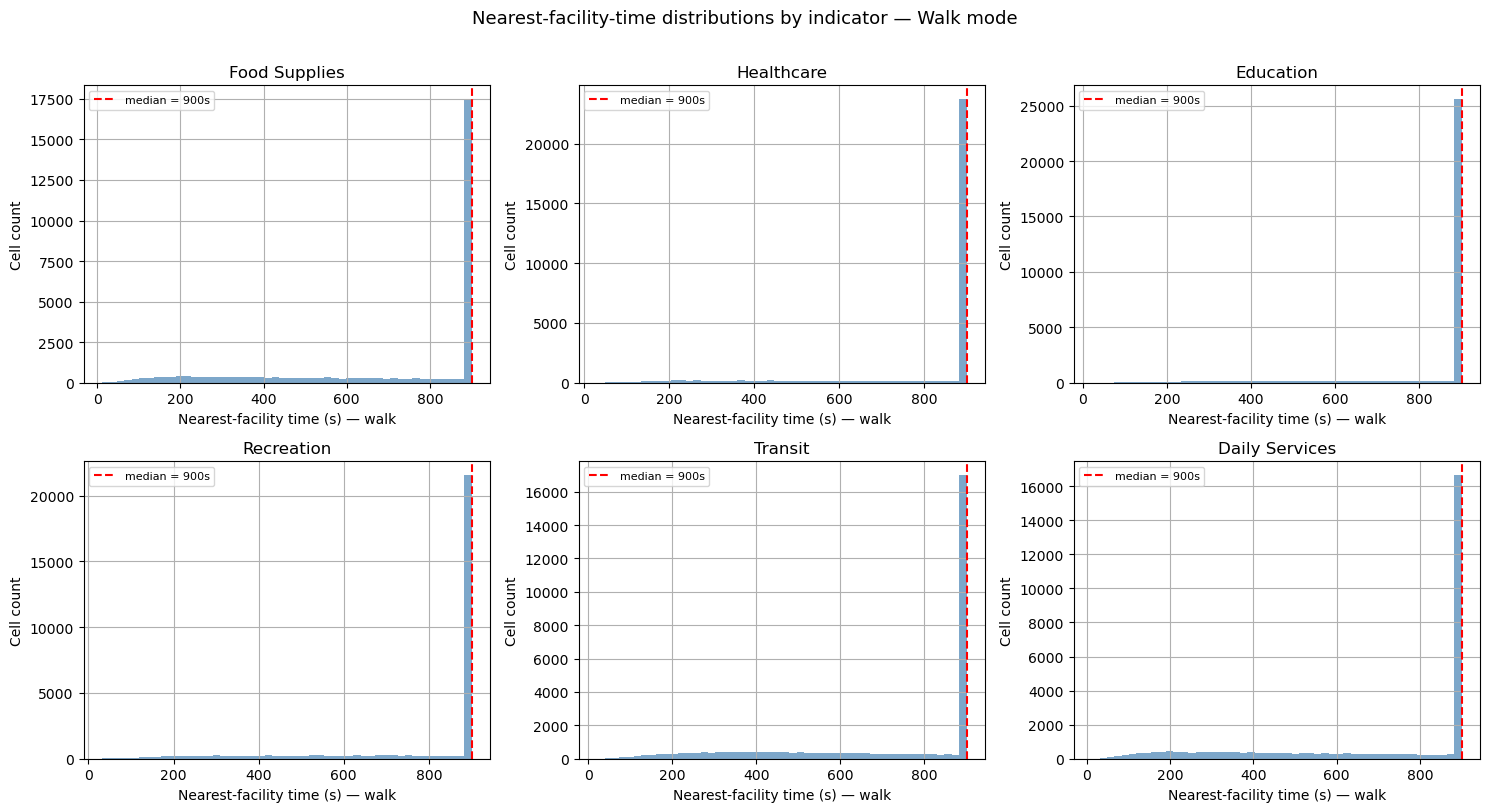

F15 by indicator and mode (fraction of cells reaching ≥1 POI within 15 min):
  indicator              walk      bike      transit   car     
  food_supplies             45.2%     83.3%     90.6%     93.0% 
  healthcare                25.1%     71.6%     84.9%     88.2% 
  education                 19.1%     63.1%     80.5%     85.2% 
  recreation                32.2%     77.9%     87.7%     90.9% 
  transit                   46.9%     84.6%     91.0%     93.2% 
  daily_services            47.9%     84.5%     91.8%     94.1% 
  employment                54.7%     86.8%     93.3%     95.2% 


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

walk_acc = accessibility[accessibility['mode'] == 'walk']

# Histograms for the 6 baseline indicators only (employment is Track-C / transit-mode,
# not a walk-baseline indicator — and there are exactly 6 subplots).
BASELINE_INDS = INDICATORS[:6]
for i, ind in enumerate(BASELINE_INDS):
    pt_col = f'pt_{ind}'
    ax = axes[i]
    walk_acc[pt_col].clip(upper=THRESHOLD_SEC).hist(
        bins=50, ax=ax, color='steelblue', alpha=0.7)
    median_val = walk_acc[pt_col].median()
    ax.axvline(median_val, color='red', linestyle='--',
               label=f'median = {median_val:.0f}s')
    ax.set_title(ind.replace('_', ' ').title())
    ax.set_xlabel('Nearest-facility time (s) — walk')
    ax.set_ylabel('Cell count')
    ax.legend(fontsize=8)

plt.suptitle('Nearest-facility-time distributions by indicator — Walk mode', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(CACHE_DIR / 'pt_distributions.png', dpi=120)
plt.show()

# F15 per indicator per mode = fraction of cells reaching ≥1 POI within 15 min
# (this is the cumulative-opportunities reachability; n>0 ⇔ pt<900).
print('F15 by indicator and mode (fraction of cells reaching ≥1 POI within 15 min):')
print(f'  {"indicator":22s}', '  '.join(f'{m:8s}' for m in MODE_SPEEDS))
for ind in INDICATORS:
    row_str = f'  {ind:22s}'
    for mode in MODE_SPEEDS:
        subset = accessibility[accessibility['mode'] == mode]
        f15 = (subset[f'n_{ind}'] > 0).mean()
        row_str += f'  {f15:7.1%} '
    print(row_str)

### 4e. Spatial Map — Geographic Distribution of PT Scores

Histograms alone can't tell us *where* the PT=900 cells are. A spatial scatter plot is the key sanity check: if the computation is correct, cells in the urban core (Jing'an, Xuhui, Huangpu, Pudong inner ring) should show **low PT scores** (green/blue → fast access), while rural Chongming Island, the Yangtze estuary coast, and the outer suburbs should show **PT=900** (red → no services reachable in 15 min on foot).

If urban-core cells showed PT=900 scattered randomly, that would flag a bug — wrong coordinate projection, disconnected graph, or mismatched node IDs. Seeing the gradient track the density gradient confirms the Dijkstra loop is correct.

We map two indicators side by side — `food_supplies` (densest POI set, most optimistic) and `healthcare` (sparser, higher PT) — to show both the typical urban core pattern and the steeper gradient of specialised services.

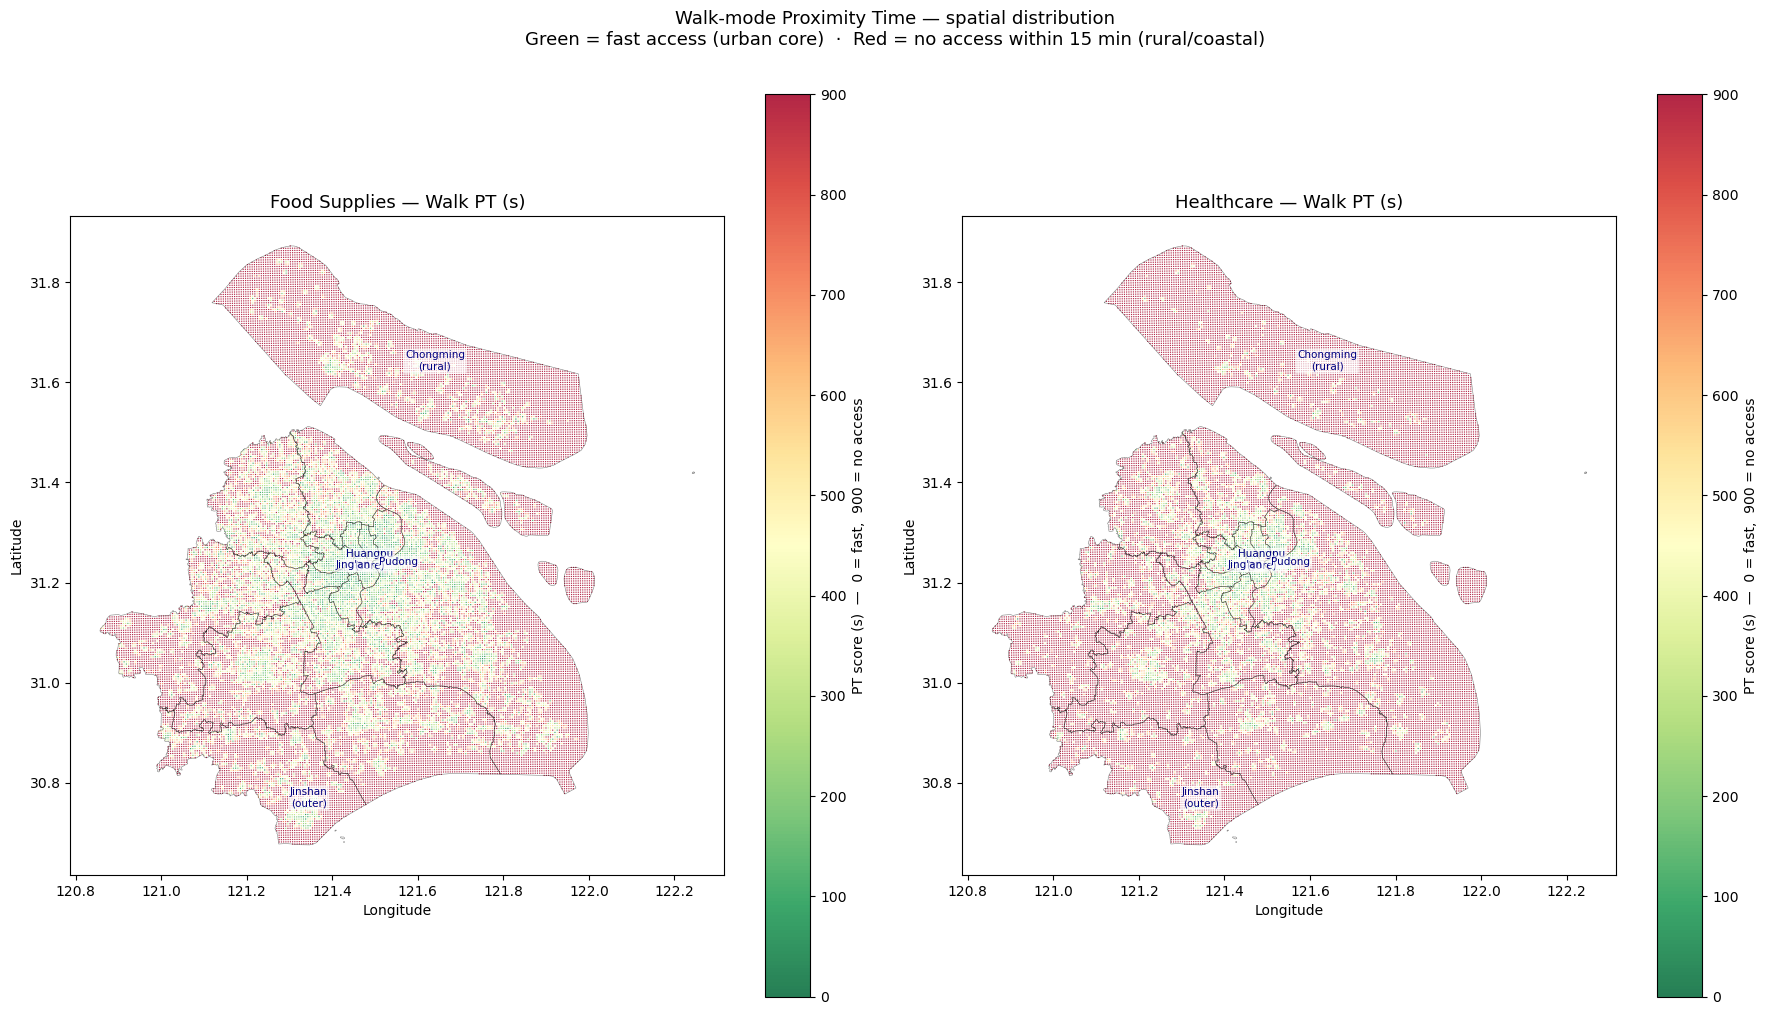

Urban-core check  (121.40–121.55°E, 31.15–31.35°N):
  Food Supplies — Walk: median 207s  |  F15 97.7%
  Healthcare — Walk PT: median 324s  |  F15 89.0%

Chongming rural check  (121.30–122.00°E, 31.50–31.90°N):
  Food Supplies — Walk: median 900s  |  F15 19.3%
  Healthcare — Walk PT: median 900s  |  F15 6.9%


In [16]:
import matplotlib.colors as mcolors

# Merge PT scores back onto grid geometry (walk mode only)
walk_acc    = accessibility[accessibility['mode'] == 'walk'].set_index('cell_id')
grid_scored = grid.set_index('cell_id').join(
    walk_acc[['pt_food_supplies', 'pt_healthcare']], how='left'
)
grid_scored = gpd.GeoDataFrame(grid_scored, geometry='geometry', crs='EPSG:4326')

# Green (fast) → Yellow → Red (slow / unreachable=900)
cmap = plt.cm.RdYlGn_r
norm = mcolors.Normalize(vmin=0, vmax=THRESHOLD_SEC)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
plot_pairs = [
    ('pt_food_supplies', 'Food Supplies — Walk PT (s)'),
    ('pt_healthcare',    'Healthcare — Walk PT (s)'),
]

for ax, (col, title) in zip(axes, plot_pairs):
    # District outlines for geographic context
    districts_gdf.to_crs('EPSG:4326').boundary.plot(
        ax=ax, color='black', linewidth=0.4, alpha=0.5)

    sc = ax.scatter(
        grid_scored.geometry.x,
        grid_scored.geometry.y,
        c=grid_scored[col].clip(upper=THRESHOLD_SEC),
        cmap=cmap, norm=norm,
        s=0.9, alpha=0.85, linewidths=0,
    )
    plt.colorbar(sc, ax=ax, label='PT score (s)  —  0 = fast,  900 = no access')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    # Orientation labels for key areas
    labels = {
        'Huangpu\n(core)':    (121.487, 31.227),
        'Pudong':              (121.555, 31.235),
        "Jing'an":             (121.448, 31.228),
        'Chongming\n(rural)': (121.640, 31.625),
        'Jinshan\n(outer)':   (121.345, 30.752),
    }
    for name, (lng, lat) in labels.items():
        ax.annotate(name, xy=(lng, lat), fontsize=7.5, color='navy',
                    ha='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              alpha=0.65, lw=0))

plt.suptitle(
    'Walk-mode Proximity Time — spatial distribution\n'
    'Green = fast access (urban core)  ·  Red = no access within 15 min (rural/coastal)',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig(CACHE_DIR / 'pt_spatial_walk.png', dpi=150, bbox_inches='tight')
plt.show()

# Spot-check: urban core (inner ring) vs Chongming (rural)
print('Urban-core check  (121.40–121.55°E, 31.15–31.35°N):')
urban_mask = (
    grid_scored.geometry.x.between(121.40, 121.55) &
    grid_scored.geometry.y.between(31.15, 31.35)
)
for col, label in plot_pairs:
    med = grid_scored.loc[urban_mask, col].median()
    f15 = (grid_scored.loc[urban_mask, col] < THRESHOLD_SEC).mean()
    print(f'  {label[:20]:20s}: median {med:.0f}s  |  F15 {f15:.1%}')

print(f'\nChongming rural check  (121.30–122.00°E, 31.50–31.90°N):')
rural_mask = (
    grid_scored.geometry.x.between(121.30, 122.00) &
    grid_scored.geometry.y.between(31.50, 31.90)
)
for col, label in plot_pairs:
    med = grid_scored.loc[rural_mask, col].median()
    f15 = (grid_scored.loc[rural_mask, col] < THRESHOLD_SEC).mean()
    print(f'  {label[:20]:20s}: median {med:.0f}s  |  F15 {f15:.1%}')

---

## Sprint 3 complete ✓

All deliverables for Notebook 02 are ready:

| File | Contents |
|------|----------|
| `cache/accessibility_matrix.parquet` | 125,780 rows — per `(cell, mode)`: `n_*` (count reachable in 15 min, the scored measure) + `pt_*` (nearest-facility time) for 6 baseline indicators + employment |
| `cache/pt_distributions.png` | Histogram of nearest-facility-time distributions per indicator (walk mode) |
| `cache/pt_spatial_walk.png` | Spatial scatter map (walk mode) |

### Interpretation summary

- The **urban core** (Huangpu, Jing'an, inner Pudong) reaches many POIs on foot — high cumulative-opportunity counts, confirming the network routes correctly.
- **Chongming Island** and the **Yangtze coast** reach almost nothing on foot (`n = 0`), as expected — sparse network, low density, no services within the **0.85 km** inclusive-walk radius.
- The **mode gradient** (walk < bike < transit ≈ car) holds: each faster mode reaches more POIs within the 15-minute window.

### Before running Notebook 03

If POI inputs or speeds changed, **delete `cache/accessibility_matrix.parquet`** and re-run Section 4
(the Dijkstra loop, ~7–10 min) so the counts reflect the current `poi_clean.parquet` and `MODE_SPEEDS`
(walk = 3.39 km/h, education without 培训机构).

### Next: Notebook 03 — Scoring & H3 Aggregation

```python
# Notebook 03 will:
# 1. Score each indicator from cumulative-opportunity LEVELS (0 / .25 / .5 / .75 / 1)  (Mouratidis 2026)
# 2. Compute the baseline composite (walk + bike, 6 indicators, equal weights)
# 3. Add Track C (Affordability): rent, income/rent, employment, social housing, amenities, equity proxies
# 4. Aggregate cell scores to H3 resolution 8 hexagons
# 5. Export scored_h3.geojson + compact JSON → web app
```